In [28]:
import h5py as h5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [29]:
# data_dict['K562'] = h5py.File(self.data_folder + '/K562_DNase_ENCFF257HEE_2kb_4DNFITUOMFUQ_enhancer_promoter_encoding.h5', 'r')
# self.data_dict['GM12878'] = h5py.File(self.data_folder + '/GM12878_DNase_ENCFF020WZB_2kb_4DNFI1UEG1HD_promoter_enhancer_encoding.h5', 'r')
data_h5 = h5.File('../data/K562_DNase_ENCFF257HEE_2kb_4DNFITUOMFUQ_enhancer_promoter_encoding.h5', 'r')

In [30]:
data_h5.keys()

<KeysViewHDF5 ['activity', 'distance', 'ensid', 'hic', 'pe_code']>

In [56]:
idx = 340
sample_ensid = data_h5['ensid'][idx].decode()
sample_ensid

'ENSG00000014138'

In [57]:
enhancer_intensity = data_h5['activity'][idx,1:]
enhancer_intensity

array([ 1.251472,  0.590729,  0.324435,  0.687039,  2.403214,  0.736926,
        0.288548,  1.358677,  4.123699,  1.144289,  1.849503,  0.472862,
        0.7835  ,  0.48115 ,  0.58489 ,  0.664494,  0.542021,  8.757148,
        0.713792,  0.866747,  0.406991,  0.335826,  1.352761,  8.18768 ,
        1.31732 , 16.296135,  1.077082,  1.127593, 15.73925 ,  6.077213,
        2.77345 ,  1.172404,  0.494121,  1.355924,  1.872691,  0.78594 ,
        1.454932,  4.924891, 11.399361, 12.353332, 27.690287,  1.545356,
        0.912476,  0.608623,  8.767563,  0.814193,  5.60847 ,  1.695786,
       11.602829,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ])

In [58]:
data_h5['distance'][idx,1:]

array([  1034. ,   4410. ,   7822. ,  11459. ,  13332. ,  25368. ,
        27969.5,  29054. ,  36175. ,  36969. ,  40200. ,  42063. ,
        46337.5,  47165.5,  48194. ,  49451. ,  50847. ,  53314.5,
        55677. ,  56924. ,  59317. ,  60453.5,  68093. ,  72004. ,
        76867. ,  80331.5,  87017. ,  90930. ,  92345.5,  92433.5,
        93434.5,  96123.5,  98078. , 100616. , 104588. , 108722. ,
       109609. , 111102.5, 120479. , 124724.5, 127104. , 128544. ,
       129284. , 139587. , 139824. , 141806. , 144214. , 144867. ,
       149467.5,      0. ,      0. ,      0. ,      0. ,      0. ,
            0. ,      0. ,      0. ,      0. ,      0. ,      0. ])

In [33]:
np.min(data_h5['distance'][:,1:])

np.float64(0.0)

In [34]:
enhancer_distance = data_h5['distance'][idx,1:]
enhancer_distance.shape

(60,)

In [59]:
# count how many enhancers are not 0 in the sample and less than 100000
enhancer_intensity[(enhancer_intensity > 0) & (enhancer_intensity < 100000)].shape[0]

49

<Axes: ylabel='Count'>

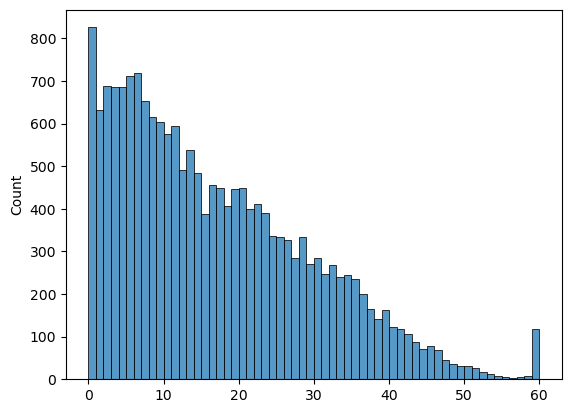

In [60]:
n_enhancers = []
index_max = -1
for idx in range(len(data_h5['ensid'])):
    enhancers = data_h5['distance'][idx,1:]
    n_enhancers.append(enhancers[(enhancers > 0) & (enhancers < 100000)].shape[0])

sns.histplot(n_enhancers, bins=60)

In [37]:
enhancer_preds = pd.read_csv('../data/K562_DNase_ENCFF257HEE_hic_4DNFITUOMFUQ_1MB_ABC_nominated/Gene-enhancer links/EnhancerPredictions.txt', sep='\t')
#enhancer_preds = pd.read_csv('../data/K562_enhancer_gene_links_100kb.tsv', sep='\t')
enhancer_preds = enhancer_preds.rename(columns={'#chr': 'chr'})
enhancer_preds

,chr,start,end,name,TargetGene,TargetGeneTSS,CellType,ABC.Score
0,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000177706,192570,K562,0.004602
1,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000197461,519217,K562,0.000001
2,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000188191,712475,K562,0.000001
3,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000164818,726698,K562,0.000588
4,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000164828,816642,K562,0.000000
...,...,...,...,...,...,...,...,...
2294541,chr19,58584250,58585301,intergenic|chr19:58584250-58585301,ENSG00000119574,58519796,K562,0.012138
2294542,chr19,58584250,58585301,intergenic|chr19:58584250-58585301,ENSG00000130726,58544455,K562,0.004453
2294543,chr19,58584250,58585301,intergenic|chr19:58584250-58585301,ENSG00000130724,58555104,K562,0.013500
2294544,chr19,58584250,58585301,intergenic|chr19:58584250-58585301,ENSG00000130725,58558921,K562,0.013500


In [38]:
sample_info = enhancer_preds[enhancer_preds['TargetGene'] == sample_ensid][['chr', 'start', 'end', 'name', 'TargetGeneTSS']]
sample_info

,chr,start,end,name,TargetGeneTSS
60054,chr7,100818222,100818855,genic|chr7:100818222-100818855,101816007
60117,chr7,100819467,100820270,genic|chr7:100819467-100820270,101816007
60180,chr7,100825307,100825807,genic|chr7:100825307-100825807,101816007
60243,chr7,100825903,100826403,genic|chr7:100825903-100826403,101816007
60305,chr7,100828365,100829025,intergenic|chr7:100828365-100829025,101816007
...,...,...,...,...,...
70285,chr7,102471160,102471768,genic|chr7:102471160-102471768,101816007
70309,chr7,102472370,102472921,genic|chr7:102472370-102472921,101816007
70333,chr7,102490476,102490976,genic|chr7:102490476-102490976,101816007
70357,chr7,102517537,102518037,intergenic|chr7:102517537-102518037,101816007


In [39]:
max_distance_down = 0
max_distance_up = 0
for i, row in sample_info.iterrows():
    down_distance = row['start'] - row['TargetGeneTSS']
    up_distance = row['TargetGeneTSS'] - row['end']
    if down_distance > max_distance_down:
        max_distance_down = down_distance
    if up_distance > max_distance_up:
        max_distance_up = up_distance
print(f'Max distance down: {max_distance_down}, Max distance up: {max_distance_up}')

Max distance down: 882881, Max distance up: 997152


In [40]:
enhancer_list = pd.read_csv("../data/K562_DNase_ENCFF257HEE_hic_4DNFITUOMFUQ_1MB_ABC_nominated/DNase_ENCFF257HEE_Neighborhoods/EnhancerList.txt", sep='\t')
enhancer_list = enhancer_list[['chr', 'start', 'end', 'name', 'activity_base', 'activity_base_no_qnorm']]
enhancer_list

,chr,start,end,name,activity_base,activity_base_no_qnorm
0,chr1,585952,586452,intergenic|chr1:585952-586452,0.088073,0.088073
1,chr1,605341,605841,intergenic|chr1:605341-605841,0.355894,0.355894
2,chr1,629686,630186,intergenic|chr1:629686-630186,0.690581,0.690581
3,chr1,633778,634278,intergenic|chr1:633778-634278,1.575716,1.575716
4,chr1,778388,779144,intergenic|chr1:778388-779144,8.205368,8.205368
...,...,...,...,...,...,...
116664,chrY,11329663,11330163,intergenic|chrY:11329663-11330163,0.931987,0.931987
116665,chrY,11333773,11334507,intergenic|chrY:11333773-11334507,0.434642,0.434642
116666,chrY,11712120,11712620,intergenic|chrY:11712120-11712620,0.044362,0.044362
116667,chrY,56849825,56850381,intergenic|chrY:56849825-56850381,0.406223,0.406223


In [41]:
# check if columns activity_base and activity_base_no_qnorm are the same
enhancer_list['activity_base'].equals(enhancer_list['activity_base_no_qnorm'])

True

In [42]:
region_names = set(sample_info['name'].values)

enhancer_list_sample = enhancer_list[enhancer_list['name'].isin(region_names)].copy()
enhancer_list_sample

,chr,start,end,name,activity_base,activity_base_no_qnorm
49129,chr7,100818222,100818855,genic|chr7:100818222-100818855,0.613978,0.613978
49130,chr7,100819467,100820270,genic|chr7:100819467-100820270,0.598320,0.598320
49131,chr7,100825307,100825807,genic|chr7:100825307-100825807,1.626300,1.626300
49132,chr7,100825903,100826403,genic|chr7:100825903-100826403,2.994416,2.994416
49134,chr7,100828365,100829025,intergenic|chr7:100828365-100829025,3.150710,3.150710
...,...,...,...,...,...,...
49424,chr7,102471160,102471768,genic|chr7:102471160-102471768,0.441856,0.441856
49425,chr7,102472370,102472921,genic|chr7:102472370-102472921,0.874890,0.874890
49427,chr7,102490476,102490976,genic|chr7:102490476-102490976,0.270739,0.270739
49429,chr7,102517537,102518037,intergenic|chr7:102517537-102518037,0.224864,0.224864


In [43]:
sample_match = []
sample_distance = []
for i, row in enhancer_list_sample.iterrows():
    # check if value appears anywhere in the enhancer_intensity
    if row['activity_base'] in enhancer_intensity:
        # find the index of the value in enhancer_intensity
        index = np.where(enhancer_intensity == row['activity_base'])[0][0]
        # check if it has already been matched
        if row['activity_base'] in sample_match:
            print(f"Duplicate match found for {row['activity_base']}")
            sample_match.append(np.nan)
            sample_distance.append(np.nan)
        if row['activity_base'] not in sample_match:
            sample_match.append(row['activity_base'])
            sample_distance.append(enhancer_distance[index])
    else:
        sample_match.append(np.nan)
        sample_distance.append(np.nan)

enhancer_list_sample['known_activity'] = sample_match
enhancer_list_sample['known_distance'] = sample_distance
enhancer_list_sample['used'] = enhancer_list_sample['known_activity'].notna()
enhancer_list_sample

,chr,start,end,name,activity_base,activity_base_no_qnorm,known_activity,known_distance,used
49129,chr7,100818222,100818855,genic|chr7:100818222-100818855,0.613978,0.613978,NaN,NaN,False
49130,chr7,100819467,100820270,genic|chr7:100819467-100820270,0.598320,0.598320,NaN,NaN,False
49131,chr7,100825307,100825807,genic|chr7:100825307-100825807,1.626300,1.626300,NaN,NaN,False
49132,chr7,100825903,100826403,genic|chr7:100825903-100826403,2.994416,2.994416,NaN,NaN,False
49134,chr7,100828365,100829025,intergenic|chr7:100828365-100829025,3.150710,3.150710,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...
49424,chr7,102471160,102471768,genic|chr7:102471160-102471768,0.441856,0.441856,NaN,NaN,False
49425,chr7,102472370,102472921,genic|chr7:102472370-102472921,0.874890,0.874890,NaN,NaN,False
49427,chr7,102490476,102490976,genic|chr7:102490476-102490976,0.270739,0.270739,NaN,NaN,False
49429,chr7,102517537,102518037,intergenic|chr7:102517537-102518037,0.224864,0.224864,NaN,NaN,False


In [44]:
sample_tss = enhancer_preds[enhancer_preds['TargetGene'] == sample_ensid]['TargetGeneTSS'].values[0]
distance_to_tss = []
for i, row in enhancer_list_sample.iterrows():
    # distance to TSS is the distance from the center of the enhancer to the TSS
    enhancer_center = (row['start'] + row['end']) / 2
    distance = abs(enhancer_center - sample_tss)
    distance_to_tss.append(distance)

enhancer_list_sample['distance_to_tss'] = distance_to_tss
enhancer_list_sample

,chr,start,end,name,activity_base,activity_base_no_qnorm,known_activity,known_distance,used,distance_to_tss
49129,chr7,100818222,100818855,genic|chr7:100818222-100818855,0.613978,0.613978,NaN,NaN,False,997468.5
49130,chr7,100819467,100820270,genic|chr7:100819467-100820270,0.598320,0.598320,NaN,NaN,False,996138.5
49131,chr7,100825307,100825807,genic|chr7:100825307-100825807,1.626300,1.626300,NaN,NaN,False,990450.0
49132,chr7,100825903,100826403,genic|chr7:100825903-100826403,2.994416,2.994416,NaN,NaN,False,989854.0
49134,chr7,100828365,100829025,intergenic|chr7:100828365-100829025,3.150710,3.150710,NaN,NaN,False,987312.0
...,...,...,...,...,...,...,...,...,...,...
49424,chr7,102471160,102471768,genic|chr7:102471160-102471768,0.441856,0.441856,NaN,NaN,False,655457.0
49425,chr7,102472370,102472921,genic|chr7:102472370-102472921,0.874890,0.874890,NaN,NaN,False,656638.5
49427,chr7,102490476,102490976,genic|chr7:102490476-102490976,0.270739,0.270739,NaN,NaN,False,674719.0
49429,chr7,102517537,102518037,intergenic|chr7:102517537-102518037,0.224864,0.224864,NaN,NaN,False,701780.0


In [45]:
enhancer_list_sample['distance_diff'] = enhancer_list_sample['known_distance'] - abs(enhancer_list_sample['distance_to_tss'])
enhancer_list_sample['region_len'] = enhancer_list_sample['end'] - enhancer_list_sample['start']
enhancer_list_sample

,chr,start,end,name,activity_base,activity_base_no_qnorm,known_activity,known_distance,used,distance_to_tss,distance_diff,region_len
49129,chr7,100818222,100818855,genic|chr7:100818222-100818855,0.613978,0.613978,NaN,NaN,False,997468.5,NaN,633
49130,chr7,100819467,100820270,genic|chr7:100819467-100820270,0.598320,0.598320,NaN,NaN,False,996138.5,NaN,803
49131,chr7,100825307,100825807,genic|chr7:100825307-100825807,1.626300,1.626300,NaN,NaN,False,990450.0,NaN,500
49132,chr7,100825903,100826403,genic|chr7:100825903-100826403,2.994416,2.994416,NaN,NaN,False,989854.0,NaN,500
49134,chr7,100828365,100829025,intergenic|chr7:100828365-100829025,3.150710,3.150710,NaN,NaN,False,987312.0,NaN,660
...,...,...,...,...,...,...,...,...,...,...,...,...
49424,chr7,102471160,102471768,genic|chr7:102471160-102471768,0.441856,0.441856,NaN,NaN,False,655457.0,NaN,608
49425,chr7,102472370,102472921,genic|chr7:102472370-102472921,0.874890,0.874890,NaN,NaN,False,656638.5,NaN,551
49427,chr7,102490476,102490976,genic|chr7:102490476-102490976,0.270739,0.270739,NaN,NaN,False,674719.0,NaN,500
49429,chr7,102517537,102518037,intergenic|chr7:102517537-102518037,0.224864,0.224864,NaN,NaN,False,701780.0,NaN,500


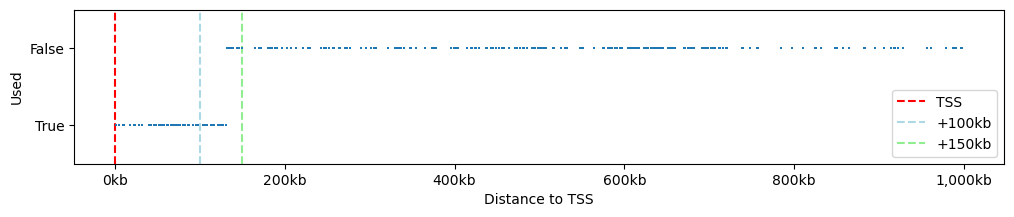

In [46]:
fig, ax = plt.subplots(figsize=(12, 2))
sns.stripplot(data=enhancer_list_sample, x='distance_to_tss', y='used', ax=ax, jitter=False, size=1, marker='s', orient='h')
# vertical line at 0
ax.axvline(x=0, color='red', linestyle='--', label='TSS')
ax.axvline(x=100_000, color='lightblue', linestyle='--', label='+100kb')
ax.axvline(x=150_000, color='lightgreen', linestyle='--', label='+150kb')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: '{:,.0f}'.format(y/1000) + 'kb'))
ax.set_xlabel('Distance to TSS')
ax.set_ylabel('Used')
ax.legend()
plt.show()

In [47]:
max_away = enhancer_list_sample[enhancer_list_sample['used'] == 1]['distance_to_tss'].max()
min_away = enhancer_list_sample[enhancer_list_sample['used'] == 1]['distance_to_tss'].min()
print(f'Max distance to TSS: {max_away}, Min distance to TSS: {min_away}')

Max distance to TSS: 130873.0, Min distance to TSS: 1792.0


# Fix this mess

In [68]:
def filter_enhancers_by_distance(enhancer_start, tss, max_distance):
    distance = abs(enhancer_start - tss)
    return distance <= max_distance

def filter_enhancers_by_promoter(enhancer_start, tss):
    # enhancers around 2kb of the tss are considered promoters and thus excluded
    return abs(enhancer_start - tss) > 1000

In [69]:
# go through enhancer_preds grouped by target gene and filter for regions by distance and promoter
# chr	start	end	name	TargetGene	TargetGeneTSS
filtered_enhancers = []
for target_gene, group in enhancer_preds.groupby('TargetGene'):
    tss = group['TargetGeneTSS'].values[0]
    group['distance'] = (group['start'] - tss).abs()
    group_sorted = group.sort_values(by='distance')
    n_enhancers = 0
    for _, row in group_sorted.iterrows():
        enhancer_start = row['start']
        if filter_enhancers_by_distance(enhancer_start, tss, 100_000) and filter_enhancers_by_promoter(enhancer_start, tss):
            filtered_tuple = (row['chr'], row['start'], row['end'], row['name'], target_gene, tss)
            filtered_enhancers.append(filtered_tuple)
            n_enhancers += 1
        if n_enhancers >= 60:
            break

filtered_enhancers_df = pd.DataFrame(filtered_enhancers, columns=['chr', 'start', 'end', 'name', 'TargetGene', 'TargetGeneTSS'])
filtered_enhancers_df

,chr,start,end,name,TargetGene,TargetGeneTSS
0,chrX,100671069,100671638,genic|chrX:100671069-100671638,ENSG00000000003,100636750
1,chrX,100674734,100675481,genic|chrX:100674734-100675481,ENSG00000000003,100636750
2,chrX,100685550,100686167,genic|chrX:100685550-100686167,ENSG00000000003,100636750
3,chrX,100512398,100513000,intergenic|chrX:100512398-100513000,ENSG00000000005,100584935
4,chrX,100671069,100671638,genic|chrX:100671069-100671638,ENSG00000000005,100584935
...,...,...,...,...,...,...
259590,chr15,84111994,84112494,intergenic|chr15:84111994-84112494,ENSG00000259511,84172490
259591,chr15,84081736,84082464,intergenic|chr15:84081736-84082464,ENSG00000259511,84172490
259592,chr15,84080642,84081142,intergenic|chr15:84080642-84081142,ENSG00000259511,84172490
259593,chr11,122202887,122203387,intergenic|chr11:122202887-122203387,ENSG00000259571,122116215


In [70]:
# merge filtered_enhancher_df with enhancer_list activity_base values (by name)
activity_enhancers_df = filtered_enhancers_df.merge(enhancer_list[['name', 'activity_base']], on='name', how='left')
activity_enhancers_df = activity_enhancers_df.rename(columns={'activity_base': 'original_activity'})
activity_enhancers_df

,chr,start,end,name,TargetGene,TargetGeneTSS,original_activity
0,chrX,100671069,100671638,genic|chrX:100671069-100671638,ENSG00000000003,100636750,0.191760
1,chrX,100674734,100675481,genic|chrX:100674734-100675481,ENSG00000000003,100636750,0.397338
2,chrX,100685550,100686167,genic|chrX:100685550-100686167,ENSG00000000003,100636750,0.555460
3,chrX,100512398,100513000,intergenic|chrX:100512398-100513000,ENSG00000000005,100584935,0.113702
4,chrX,100671069,100671638,genic|chrX:100671069-100671638,ENSG00000000005,100584935,0.191760
...,...,...,...,...,...,...,...
259590,chr15,84111994,84112494,intergenic|chr15:84111994-84112494,ENSG00000259511,84172490,0.411737
259591,chr15,84081736,84082464,intergenic|chr15:84081736-84082464,ENSG00000259511,84172490,0.629803
259592,chr15,84080642,84081142,intergenic|chr15:84080642-84081142,ENSG00000259511,84172490,0.133570
259593,chr11,122202887,122203387,intergenic|chr11:122202887-122203387,ENSG00000259571,122116215,0.284683


<Axes: xlabel='n_enhancers', ylabel='Count'>

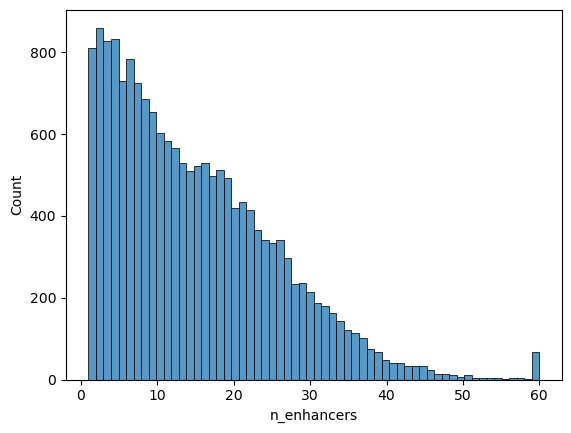

In [67]:
# group by target gene and count how many enhancers are linked to it and histplot it
activity_enhancers_df['n_enhancers'] = activity_enhancers_df.groupby('TargetGene')['name'].transform('count')
# plot the distribution of n_enhancers per gene => ONLY COUNT EACH GENE ONCE
n_enhancers_per_gene = activity_enhancers_df.drop_duplicates(subset=['TargetGene'])['n_enhancers']
sns.histplot(n_enhancers_per_gene, bins=60)